# Fase 3 — Embedding propio con FastText (skip-gram)

**Proyecto:** Clasificador de artículos científicos CS → Grafo de conocimiento UAM-A  
**Objetivo:** Entrenar un modelo FastText sobre Wikipedia EN + arXiv CS para generar la capa de embedding de la BiLSTM (Fase 4).  
**Corpus de entrenamiento:** Wikipedia EN (vía gensim) + abstracts del corpus arXiv CS completo  
**Resultado esperado:** `fasttext_cs_wiki.model`, `embedding_matrix.npy`, `vocab2idx.pkl`

---
## Celda 1 — Imports y configuración

In [6]:
# ============================================================
# Imports
# ============================================================
import re
import logging
import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

from gensim.models import FastText
import gensim.downloader as api

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from tqdm.auto import tqdm

# Logging para monitorear progreso de gensim por época
logging.basicConfig(
    format='%(asctime)s : %(levelname)s : %(message)s',
    level=logging.INFO
)

# ============================================================
# Hiperparámetros del modelo FastText
# ============================================================
VECTOR_SIZE = 300       
WINDOW      = 5         
MIN_COUNT   = 5         
SG          = 1         
EPOCHS      = 10        
WORKERS     = 36       

# ============================================================
# Rutas de archivos
# ============================================================
# --- Entradas ---
ARXIV_TOP10_AUG   = r"D:\Aaron\arxiv_cs_top10_augmented.parquet"   # Corpus Top 10 aumentado
ARXIV_CS_FULL     = r"C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs.parquet"                   # Corpus arXiv CS completo (opcional)

# --- Salidas ---

now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

FASTTEXT_MODEL    = r"D:\Aaron\fasttext_cs_wiki_"  +date_time + "_.model"             
EMBEDDING_MATRIX  = r"D:\Aaron\embedding_matrix_"  +date_time + "_.npy"               
VOCAB2IDX_FILE    = r"D:\Aaron\vocab2idx_"  +date_time + "_.pkl"                      

# ============================================================
# Utilidades
# ============================================================
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)       # Solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip()    # Colapsar espacios
    tokens = text.split()
    tokens = [t for t in tokens if 2 <= len(t) <= 50]
    return tokens

def report_memory(tag=""):
    """Imprime el uso actual de RAM del proceso."""
    proc = psutil.Process(os.getpid())
    mem = proc.memory_info().rss / (1024 ** 3)  # GB
    print(f"[MEM {tag}] RSS = {mem:.2f} GB")

report_memory("inicio")
print("\n Imports y configuración completados.")
print(f"   FastText: vector_size={VECTOR_SIZE}, window={WINDOW}, "
      f"min_count={MIN_COUNT}, sg={SG}, epochs={EPOCHS}, workers={WORKERS}")

[MEM inicio] RSS = 2.17 GB

 Imports y configuración completados.
   FastText: vector_size=300, window=5, min_count=5, sg=1, epochs=10, workers=36


---
## Celda 2 — Carga y preprocesamiento del corpus arXiv CS

In [7]:
# ============================================================
# Cargar corpus Top 10 aumentado (texto_limpio)
# ============================================================
report_memory("antes de cargar arXiv Top 10")

df_top10 = pd.read_parquet(ARXIV_TOP10_AUG, columns=["texto_limpio"])
arxiv_top10_sentences = df_top10["texto_limpio"].dropna().tolist()
del df_top10  # Liberar DataFrame, nos quedamos solo con la lista de strings

print(f"arXiv Top 10 aumentado: {len(arxiv_top10_sentences):,} documentos")
report_memory("después de cargar arXiv Top 10")

# ============================================================
# Cargar corpus arXiv CS completo (si existe)
# ============================================================
arxiv_full_sentences = []

if os.path.exists(ARXIV_CS_FULL):
    print(f"\nArchivo '{ARXIV_CS_FULL}' encontrado — cargando corpus arXiv CS completo...")
    report_memory("antes de cargar arXiv CS completo")
    
    df_full = pd.read_parquet(ARXIV_CS_FULL, columns=["abstract"])
    arxiv_full_sentences = df_full["abstract"].dropna().tolist()
    del df_full
    
    print(f"arXiv CS completo: {len(arxiv_full_sentences):,} documentos")
    report_memory("después de cargar arXiv CS completo")
else:
    print(f"\n Archivo '{ARXIV_CS_FULL}' no encontrado.")
    print("   Se usará únicamente el corpus Top 10 aumentado para la parte arXiv.")

# ============================================================
# Tokenización con limpieza (clean_and_tokenize)
# ============================================================
print("\nTokenizando corpus arXiv con limpieza...")

arxiv_tokenized = []

# Top 10
for text in tqdm(arxiv_top10_sentences, desc="Limpiando+tokenizando Top 10"):
    arxiv_tokenized.append(clean_and_tokenize(text))

# Corpus completo
if arxiv_full_sentences:
    for text in tqdm(arxiv_full_sentences, desc="Limpiando+tokenizando arXiv CS completo"):
        arxiv_tokenized.append(clean_and_tokenize(text))

# Liberar listas de strings crudos
del arxiv_top10_sentences, arxiv_full_sentences

# Estadísticas
total_tokens_arxiv = sum(len(sent) for sent in arxiv_tokenized)
print(f"\n Corpus arXiv tokenizado (limpio):")
print(f"   Documentos: {len(arxiv_tokenized):,}")
print(f"   Tokens totales: {total_tokens_arxiv:,}")
print(f"   Tokens promedio por doc: {total_tokens_arxiv / len(arxiv_tokenized):.1f}")
report_memory("después de tokenizar arXiv")

[MEM antes de cargar arXiv Top 10] RSS = 2.17 GB
arXiv Top 10 aumentado: 713,063 documentos
[MEM después de cargar arXiv Top 10] RSS = 2.23 GB

Archivo 'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_cs.parquet' encontrado — cargando corpus arXiv CS completo...
[MEM antes de cargar arXiv CS completo] RSS = 1.16 GB
arXiv CS completo: 892,992 documentos
[MEM después de cargar arXiv CS completo] RSS = 2.19 GB

Tokenizando corpus arXiv con limpieza...


Limpiando+tokenizando arXiv CS completo: 100%|███████████████████████████████| 892992/892992 [02:27<00:00, 6067.52it/s]



 Corpus arXiv tokenizado (limpio):
   Documentos: 1,606,055
   Tokens totales: 256,780,173
   Tokens promedio por doc: 159.9
[MEM después de tokenizar arXiv] RSS = 18.01 GB


---
## Celda 3 — Descarga y preprocesamiento de Wikipedia EN

In [8]:
# ============================================================
# Descargar Wikipedia EN vía gensim.downloader
# ============================================================

report_memory("antes de cargar Wikipedia")
print("Cargando corpus Wikipedia EN (gensim 'wiki-english-20171001')...")
print("Si es la primera vez, se descargará (~4.7 GB comprimido).")
print("Esto puede tomar varios minutos...\n")

t0 = time.time()
wiki_corpus_raw = api.load("wiki-english-20171001")

print("Cargando Wikipedia en memoria ...")
wiki_tokenized = []
wiki_token_count = 0

for article in tqdm(wiki_corpus_raw, desc="Cargando artículos Wikipedia"):
    if len(article) > 0:
        # Reunir tokens, limpiar como string, re-tokenizar
        cleaned = clean_and_tokenize(' '.join(article))
        if len(cleaned) > 0:
            wiki_tokenized.append(cleaned)
            wiki_token_count += len(cleaned)

elapsed = time.time() - t0
print(f"\n Corpus Wikipedia EN:")
print(f"   Artículos/secciones: {len(wiki_tokenized):,}")
print(f"   Tokens totales: {wiki_token_count:,}")
print(f"   Tiempo de carga: {elapsed:.1f} s")
report_memory("después de cargar Wikipedia")

[MEM antes de cargar Wikipedia] RSS = 18.01 GB
Cargando corpus Wikipedia EN (gensim 'wiki-english-20171001')...
Si es la primera vez, se descargará (~4.7 GB comprimido).
Esto puede tomar varios minutos...

Cargando Wikipedia en memoria ...


Cargando artículos Wikipedia: 4924894it [06:15, 13130.06it/s]


 Corpus Wikipedia EN:
   Artículos/secciones: 4,924,894
   Tokens totales: 14,774,682
   Tiempo de carga: 375.3 s
[MEM después de cargar Wikipedia] RSS = 19.38 GB


---
## Celda 4 — Construcción del corpus combinado

In [9]:
# ============================================================
# Corpus combinado como clase iterable
# ============================================================

class CombinedCorpus:
    """Iterable que concatena múltiples listas de oraciones tokenizadas.
    
    Permite iterar múltiples veces (requerido por gensim FastText)
    sin duplicar los datos en memoria.
    """
    def __init__(self, *corpora):
        self.corpora = corpora
        self._total_docs = sum(len(c) for c in corpora)
    
    def __iter__(self):
        for corpus in self.corpora:
            yield from corpus
    
    def __len__(self):
        return self._total_docs


combined_corpus = CombinedCorpus(arxiv_tokenized, wiki_tokenized)

# Estadísticas del corpus combinado
total_docs = len(combined_corpus)
total_tokens_combined = total_tokens_arxiv + wiki_token_count

print(" Corpus combinado (arXiv CS + Wikipedia EN):")
print(f"   Documentos/secciones totales: {total_docs:,}")
print(f"   Tokens totales estimados:     {total_tokens_combined:,}")
print(f"   Proporción arXiv:  {len(arxiv_tokenized)/total_docs*100:.1f}%")
print(f"   Proporción Wiki:   {len(wiki_tokenized)/total_docs*100:.1f}%")
report_memory("corpus combinado listo")

 Corpus combinado (arXiv CS + Wikipedia EN):
   Documentos/secciones totales: 6,530,949
   Tokens totales estimados:     271,554,855
   Proporción arXiv:  24.6%
   Proporción Wiki:   75.4%
[MEM corpus combinado listo] RSS = 19.38 GB


---
## Celda 5 — Entrenamiento del modelo FastText

In [10]:
# ============================================================
# Entrenamiento de FastText (skip-gram)
# ============================================================

report_memory("antes de entrenar FastText")

print("Iniciando entrenamiento de FastText...")
print(f"   Parámetros: vector_size={VECTOR_SIZE}, window={WINDOW}, "
      f"min_count={MIN_COUNT}, sg={SG}, epochs={EPOCHS}, workers={WORKERS}")
print(f"   Corpus: {total_docs:,} documentos, ~{total_tokens_combined:,} tokens")
print("   Entrenando...\n")

t0 = time.time()

model = FastText(
    sentences=combined_corpus,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    sg=SG,
    epochs=EPOCHS,
    workers=WORKERS,
    seed=42,
    # Parámetros de subpalabras (defaults de FastText original)
    min_n=3,      # n-grama mínimo de caracteres
    max_n=6,      # n-grama máximo de caracteres
)

elapsed = time.time() - t0
hours, remainder = divmod(elapsed, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"\n Entrenamiento completado.")
print(f"   Tiempo total: {int(hours)}h {int(minutes)}m {int(seconds)}s")
print(f"   Vocabulario del modelo: {len(model.wv):,} palabras")
report_memory("después de entrenar FastText")

# ============================================================
# Guardar modelo
# ============================================================
model.save(FASTTEXT_MODEL)
print(f"\n Modelo guardado: {FASTTEXT_MODEL}")
print(f"   Tamaño en disco: {os.path.getsize(FASTTEXT_MODEL) / (1024**3):.2f} GB")

2026-04-01 10:29:54,068 : INFO : collecting all words and their counts
2026-04-01 10:29:54,070 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


[MEM antes de entrenar FastText] RSS = 19.38 GB
Iniciando entrenamiento de FastText...
   Parámetros: vector_size=300, window=5, min_count=5, sg=1, epochs=10, workers=36
   Corpus: 6,530,949 documentos, ~271,554,855 tokens
   Entrenando...



2026-04-01 10:29:54,392 : INFO : PROGRESS: at sentence #10000, processed 1579395 words, keeping 47239 word types
2026-04-01 10:29:54,729 : INFO : PROGRESS: at sentence #20000, processed 3156206 words, keeping 71831 word types
2026-04-01 10:29:55,092 : INFO : PROGRESS: at sentence #30000, processed 4739179 words, keeping 92272 word types
2026-04-01 10:29:55,492 : INFO : PROGRESS: at sentence #40000, processed 6313719 words, keeping 110499 word types
2026-04-01 10:29:55,818 : INFO : PROGRESS: at sentence #50000, processed 7891930 words, keeping 127190 word types
2026-04-01 10:29:56,164 : INFO : PROGRESS: at sentence #60000, processed 9464461 words, keeping 142591 word types
2026-04-01 10:29:56,533 : INFO : PROGRESS: at sentence #70000, processed 11046516 words, keeping 157650 word types
2026-04-01 10:29:56,918 : INFO : PROGRESS: at sentence #80000, processed 12630830 words, keeping 172086 word types
2026-04-01 10:29:57,311 : INFO : PROGRESS: at sentence #90000, processed 14215874 words, 


 Entrenamiento completado.
   Tiempo total: 2h 5m 37s
   Vocabulario del modelo: 294,292 palabras
[MEM después de entrenar FastText] RSS = 22.69 GB


2026-04-01 12:35:32,908 : INFO : storing np array 'vectors_ngrams' to D:\Aaron\fasttext_cs_wiki_01_04_2026_09_39_20_.model.wv.vectors_ngrams.npy
2026-04-01 12:35:42,801 : INFO : not storing attribute buckets_word
2026-04-01 12:35:42,804 : INFO : storing np array 'syn1neg' to D:\Aaron\fasttext_cs_wiki_01_04_2026_09_39_20_.model.syn1neg.npy
2026-04-01 12:35:44,214 : INFO : not storing attribute cum_table
2026-04-01 12:35:44,432 : INFO : saved D:\Aaron\fasttext_cs_wiki_01_04_2026_09_39_20_.model



 Modelo guardado: D:\Aaron\fasttext_cs_wiki_01_04_2026_09_39_20_.model
   Tamaño en disco: 0.01 GB


---
## Celda 6 — Validación semántica del embedding

In [11]:
# from gensim.models import FastText
# model = FastText.load("fasttext_cs_wiki.model")

print("=" * 70)
print("VALIDACIÓN SEMÁNTICA DEL EMBEDDING")
print("=" * 70)

# Consultas most_similar 
queries = [
    ("neural",        "cs.AI/LG — debe devolver 'network', 'convolutional', 'deep'"),
    ("cryptography",  "cs.CR — debe devolver términos de seguridad/cifrado"),
    ("robot",         "cs.RO — debe devolver términos de robótica"),
    ("algorithm",     "cs.DS — debe devolver términos de algoritmos"),
    ("parsing",       "cs.CL — debe devolver términos de NLP/lenguaje"),
]

for word, description in queries:
    print(f"\n most_similar('{word}')  [{description}]")
    print(f"   {'Término':<25} {'Similitud':>10}")
    print(f"   {'─'*25} {'─'*10}")
    try:
        neighbors = model.wv.most_similar(word, topn=10)
        for term, score in neighbors:
            print(f"   {term:<25} {score:>10.4f}")
    except KeyError:
        print(f"    '{word}' no está en el vocabulario (se usará vector de subpalabras)")
        # FastText puede generar vector para OOV via subwords
        neighbors = model.wv.most_similar(positive=[model.wv[word]], topn=10)
        for term, score in neighbors:
            print(f"   {term:<25} {score:>10.4f}")

# Pares de similitud esperados 
print("\n" + "=" * 70)
print("PARES DE SIMILITUD")
print("=" * 70)

similarity_pairs = [
    ("machine",      "learning",      "alta (mismo dominio)"),
    ("deep",         "learning",      "alta (mismo dominio)"),
    ("neural",       "network",       "alta (mismo dominio)"),
    ("cryptography", "encryption",    "alta (mismo dominio)"),
    ("robot",        "manipulation",  "media-alta (cs.RO)"),
    ("cryptography", "robotics",      "baja (dominios distintos)"),
    ("parsing",      "encryption",    "baja (dominios distintos)"),
]

print(f"\n   {'Par':<40} {'Similitud':>10} {'Esperado':<25}")
print(f"   {'─'*40} {'─'*10} {'─'*25}")

for w1, w2, expected in similarity_pairs:
    try:
        sim = model.wv.similarity(w1, w2)
        print(f"   {w1 + ' ↔ ' + w2:<40} {sim:>10.4f} {expected:<25}")
    except KeyError as e:
        print(f"   {w1 + ' ↔ ' + w2:<40} {'OOV':>10} {str(e)}")

print("\n Validación semántica completada.")

VALIDACIÓN SEMÁNTICA DEL EMBEDDING

 most_similar('neural')  [cs.AI/LG — debe devolver 'network', 'convolutional', 'deep']
   Término                    Similitud
   ───────────────────────── ──────────
   neuralized                    0.7471
   spneural                      0.7353
   rxneural                      0.7351
   metaneural                    0.7301
   interneural                   0.7245
   preneural                     0.7156
   neuraldater                   0.7071
   recurrentneural               0.7061
   neurall                       0.7037
   recurrentneuralnetworkbased     0.7007

 most_similar('cryptography')  [cs.CR — debe devolver términos de seguridad/cifrado]
   Término                    Similitud
   ───────────────────────── ──────────
   cryptographys                 0.9285
   cryptographics                0.9087
   cryptograph                   0.8860
   cryptographic                 0.8731
   cryptogram                    0.8693
   noncryptography           

---
## Celda 7 — Construcción de la matriz de embeddings

In [12]:
# ============================================================
# Construir vocabulario del corpus arXiv Top 10 aumentado
# y extraer la matriz de embeddings correspondiente.
# ============================================================

report_memory("antes de construir matriz de embeddings")

# Construir vocabulario desde texto_limpio 
print("Construyendo vocabulario del corpus arXiv Top 10 aumentado...")

df_vocab = pd.read_parquet(ARXIV_TOP10_AUG, columns=["texto_limpio"])
texts = df_vocab["texto_limpio"].dropna()

token_counter = Counter()
for text in tqdm(texts, desc="Contando tokens"):
    token_counter.update(clean_and_tokenize(text))

del df_vocab, texts

# Filtrar tokens con frecuencia >= MIN_COUNT
vocab_tokens = [token for token, count in token_counter.items() if count >= MIN_COUNT]
vocab_tokens.sort()  # Orden determinista

print(f"   Tokens únicos totales: {len(token_counter):,}")
print(f"   Tokens con freq >= {MIN_COUNT}: {len(vocab_tokens):,}")

# Construir vocab2idx (0 = <PAD>, 1 = <UNK>) 
vocab2idx = {"<PAD>": 0, "<UNK>": 1}
for i, token in enumerate(vocab_tokens, start=2):
    vocab2idx[token] = i

vocab_size = len(vocab2idx)
print(f"   Tamaño del vocabulario (con <PAD> y <UNK>): {vocab_size:,}")

# --- 7c. Construir la matriz de embeddings ---
print(f"\nConstruyendo matriz de embeddings ({vocab_size:,} × {VECTOR_SIZE})...")

embedding_matrix = np.zeros((vocab_size, VECTOR_SIZE), dtype=np.float32)

# <PAD> queda como vector cero (índice 0)
# <UNK> se inicializa con distribución normal pequeña
np.random.seed(42)
embedding_matrix[1] = np.random.normal(scale=0.1, size=VECTOR_SIZE)  # <UNK>

# Contadores de cobertura
in_vocab_count = 0
oov_subword_count = 0

for token, idx in tqdm(vocab2idx.items(), desc="Extrayendo vectores", total=vocab_size):
    if token in ("<PAD>", "<UNK>"):
        continue
    
    if token in model.wv.key_to_index:
        # Token presente directamente en el vocabulario del modelo
        embedding_matrix[idx] = model.wv[token]
        in_vocab_count += 1
    else:
        # Token OOV: FastText genera vector usando n-gramas de caracteres
        embedding_matrix[idx] = model.wv[token]  # FastText maneja OOV automáticamente
        oov_subword_count += 1

total_real_tokens = vocab_size - 2  # Excluir <PAD> y <UNK>
coverage = in_vocab_count / total_real_tokens * 100 if total_real_tokens > 0 else 0

print(f"\n Cobertura del embedding:")
print(f"   Tokens con vector directo:    {in_vocab_count:,} ({coverage:.1f}%)")
print(f"   Tokens OOV (vector subword):  {oov_subword_count:,} ({100-coverage:.1f}%)")
print(f"   Tamaño de la matriz:          {embedding_matrix.shape}")
print(f"   Memoria de la matriz:         {embedding_matrix.nbytes / (1024**2):.1f} MB")

# Guardar 
np.save(EMBEDDING_MATRIX, embedding_matrix)
print(f"\n Matriz guardada: {EMBEDDING_MATRIX}")

with open(VOCAB2IDX_FILE, "wb") as f:
    pickle.dump(vocab2idx, f)
print(f" Vocabulario guardado: {VOCAB2IDX_FILE} ({vocab_size:,} tokens)")

report_memory("después de construir matriz")

# Verificación rápida de compatibilidad con PyTorch 
import torch

emb_tensor = torch.from_numpy(embedding_matrix)
emb_layer = torch.nn.Embedding.from_pretrained(emb_tensor, freeze=False, padding_idx=0)

# Test: pasar un mini-batch de índices
test_indices = torch.tensor([0, 1, 2, 3])  # <PAD>, <UNK>, primer token, segundo token
test_output = emb_layer(test_indices)
print(f"\n Verificación PyTorch:")
print(f"   Embedding layer shape: {emb_layer.weight.shape}")
print(f"   Test forward pass: input {test_indices.shape} → output {test_output.shape}")
print(f"   <PAD> vector norma (debe ser ~0): {torch.norm(test_output[0]).item():.6f}")
print("    Compatible con PyTorch nn.Embedding")

del emb_tensor, emb_layer, test_indices, test_output  # Liberar

[MEM antes de construir matriz de embeddings] RSS = 22.69 GB
Construyendo vocabulario del corpus arXiv Top 10 aumentado...


Contando tokens: 100%|███████████████████████████████████████████████████████| 713063/713063 [01:51<00:00, 6394.43it/s]


   Tokens únicos totales: 725,157
   Tokens con freq >= 5: 147,007
   Tamaño del vocabulario (con <PAD> y <UNK>): 147,009

Construyendo matriz de embeddings (147,009 × 300)...


Extrayendo vectores: 100%|█████████████████████████████████████████████████| 147009/147009 [00:00<00:00, 177041.38it/s]



 Cobertura del embedding:
   Tokens con vector directo:    147,007 (100.0%)
   Tokens OOV (vector subword):  0 (0.0%)
   Tamaño de la matriz:          (147009, 300)
   Memoria de la matriz:         168.2 MB

 Matriz guardada: D:\Aaron\embedding_matrix_01_04_2026_09_39_20_.npy
 Vocabulario guardado: D:\Aaron\vocab2idx_01_04_2026_09_39_20_.pkl (147,009 tokens)
[MEM después de construir matriz] RSS = 22.98 GB

🔧 Verificación PyTorch:
   Embedding layer shape: torch.Size([147009, 300])
   Test forward pass: input torch.Size([4]) → output torch.Size([4, 300])
   <PAD> vector norma (debe ser ~0): 0.000000
    Compatible con PyTorch nn.Embedding


---
## Celda 8 — Visualización con PCA + t-SNE

Términos seleccionados para visualización: 200
Calculando asociación término → categoría cs.*...
Vectores extraídos: (200, 300)
Distribución por categoría:
   cs.AI: 7
   cs.CL: 28
   cs.CR: 19
   cs.CV: 39
   cs.DS: 39
   cs.IT: 12
   cs.LG: 9
   cs.NA: 20
   cs.RO: 12
   cs.SY: 15

Reduciendo dimensionalidad: PCA(50D) → t-SNE(2D)...
   PCA: varianza explicada = 65.6%
   t-SNE: completado.

 Figura guardada: embedding_tsne_top200.png


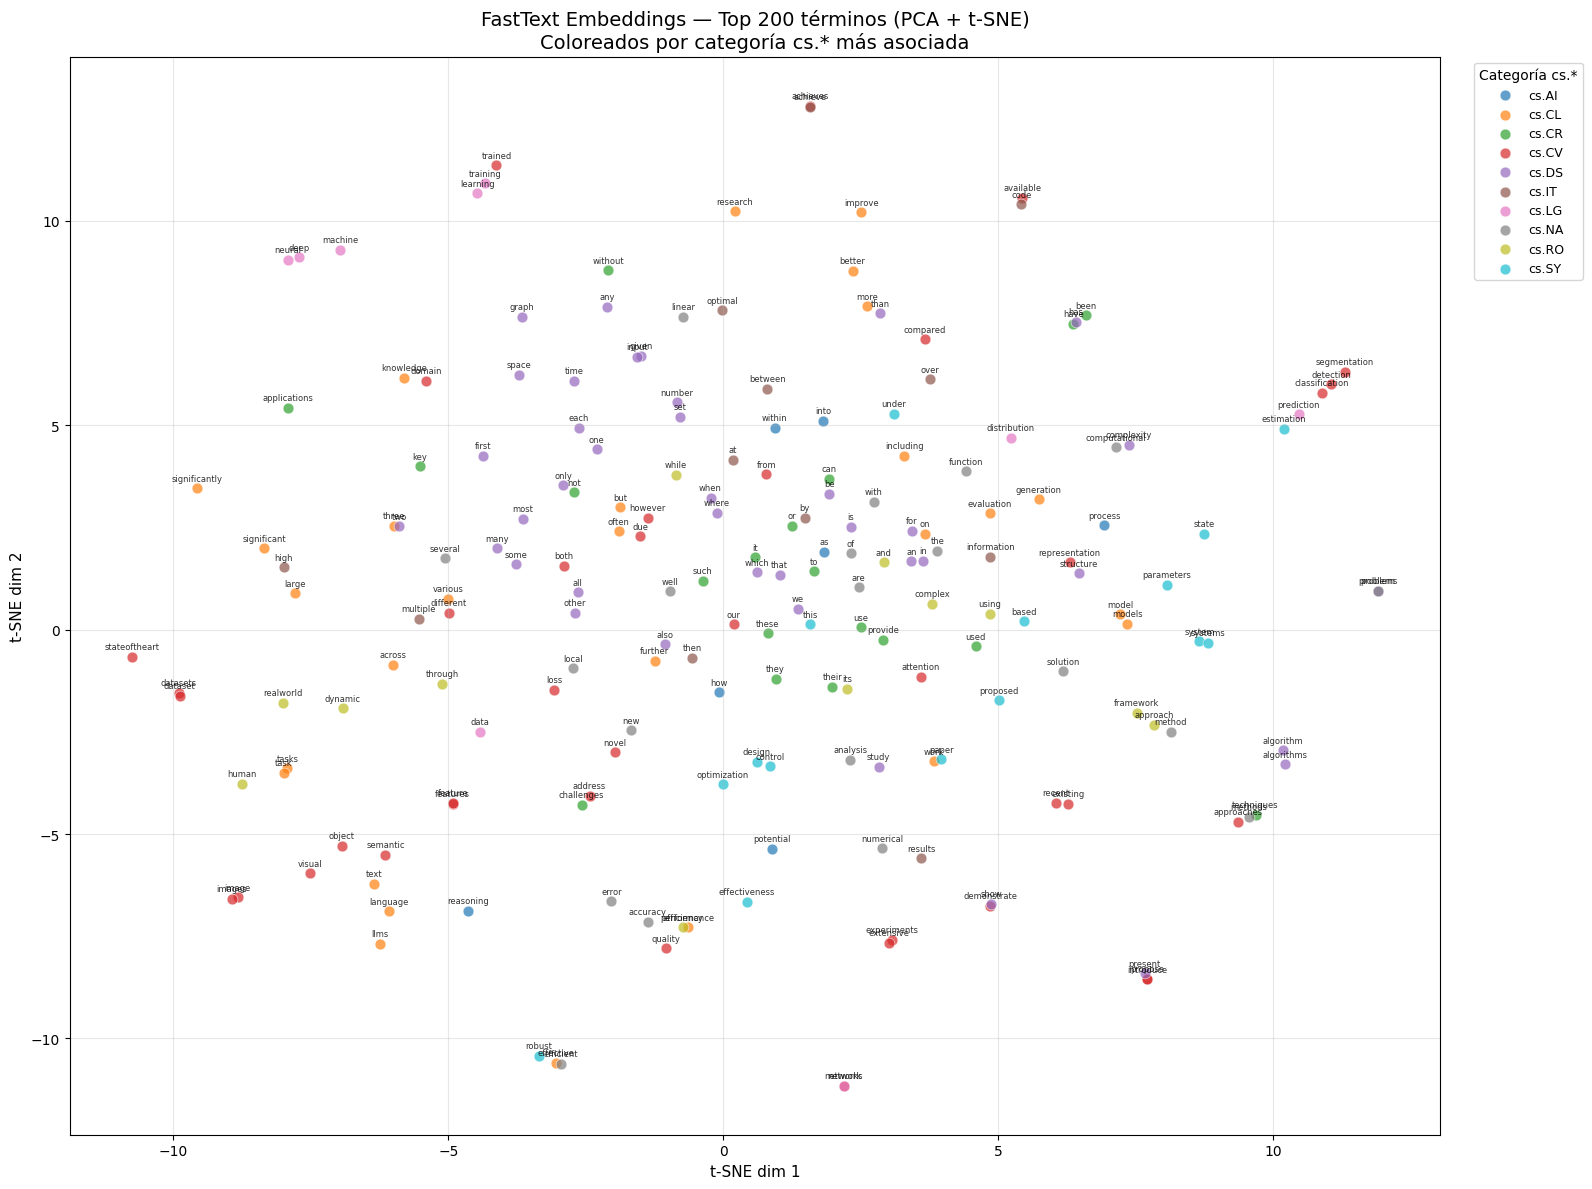

[MEM fin de visualización] RSS = 24.32 GB


In [15]:
# ============================================================
# Seleccionamos los 200 términos más frecuentes del vocabulario
# arXiv Top 10 y los coloreamos por la categoría cs.* a la que
# se asocian más fuertemente.
# ============================================================

# Seleccionar los 200 términos más frecuentes 
top_200 = [token for token, _ in token_counter.most_common(200) if token in vocab2idx]
top_200 = top_200[:200]  # Asegurar exactamente 200

print(f"Términos seleccionados para visualización: {len(top_200)}")

# Asignar cada término a la categoría cs.* más asociada 
# Para esto, calculamos la frecuencia relativa de cada término en cada clase.

print("Calculando asociación término → categoría cs.*...")
df_assoc = pd.read_parquet(ARXIV_TOP10_AUG, columns=["texto_limpio", "cs_primary", "aug_method"])
# Usar solo datos originales para la asociación (evitar sesgo de augmentación)
df_orig = df_assoc[df_assoc["aug_method"] == "original"]

categories = df_orig["cs_primary"].unique().tolist()

# Contar frecuencia de cada término en cada categoría
class_token_counts = {}
for cat in categories:
    mask = df_orig["cs_primary"] == cat
    texts_cat = df_orig.loc[mask, "texto_limpio"].dropna()
    counter = Counter()
    for text in texts_cat:
        counter.update(text.split())
    class_token_counts[cat] = counter

del df_assoc, df_orig

# Asignar cada término al dominio donde tiene mayor frecuencia relativa (TF-IDF-like)
# Usamos proporción: freq(term, class) / total_tokens(class)
class_totals = {cat: sum(cnt.values()) for cat, cnt in class_token_counts.items()}

term_to_category = {}
for term in top_200:
    best_cat = None
    best_score = -1
    for cat in categories:
        freq = class_token_counts[cat].get(term, 0)
        score = freq / class_totals[cat] if class_totals[cat] > 0 else 0
        if score > best_score:
            best_score = score
            best_cat = cat
    term_to_category[term] = best_cat

# Extraer vectores de los 200 términos 
vectors_200 = np.array([embedding_matrix[vocab2idx[t]] for t in top_200])
labels_200 = [term_to_category[t] for t in top_200]

print(f"Vectores extraídos: {vectors_200.shape}")
print(f"Distribución por categoría:")
cat_dist = Counter(labels_200)
for cat, count in sorted(cat_dist.items()):
    print(f"   {cat}: {count}")

# PCA (300D → 50D) + t-SNE (50D → 2D) 
print("\nReduciendo dimensionalidad: PCA(50D) → t-SNE(2D)...")

pca = PCA(n_components=50, random_state=42)
vectors_pca = pca.fit_transform(vectors_200)
print(f"   PCA: varianza explicada = {pca.explained_variance_ratio_.sum()*100:.1f}%")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
vectors_2d = tsne.fit_transform(vectors_pca)
print("   t-SNE: completado.")

# Graficar 
fig, ax = plt.subplots(figsize=(16, 12))

# Paleta de colores para las 10 categorías
unique_cats = sorted(set(labels_200))
palette = sns.color_palette("tab10", n_colors=len(unique_cats))
cat_to_color = {cat: palette[i] for i, cat in enumerate(unique_cats)}

# Scatter plot
for cat in unique_cats:
    mask = [i for i, l in enumerate(labels_200) if l == cat]
    ax.scatter(
        vectors_2d[mask, 0], vectors_2d[mask, 1],
        c=[cat_to_color[cat]], label=cat, s=60, alpha=0.7, edgecolors='white', linewidths=0.5
    )

# Anotar los términos
for i, term in enumerate(top_200):
    ax.annotate(
        term,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        fontsize=6, alpha=0.8,
        ha='center', va='bottom',
        xytext=(0, 4), textcoords='offset points'
    )

ax.set_title("FastText Embeddings — Top 200 términos (PCA + t-SNE)\n"
             "Coloreados por categoría cs.* más asociada", fontsize=14)
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Categoría cs.*", bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=9, title_fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar figura
fig.savefig("embedding_tsne_top200.png", dpi=150, bbox_inches='tight')
print("\n Figura guardada: embedding_tsne_top200.png")
plt.show()

report_memory("fin de visualización")

Cargando datos para asociación término → categoría...
Seleccionando términos discriminantes por categoría...

Términos seleccionados: 149

Distribución por categoría:
   cs.AI:  15  (logics, consciousness, asp, argumentation, kgs, ...)
   cs.CL:  15  (nmt, monolingual, multilingual, english, corpus, ...)
   cs.CR:  15  (malware, cryptographic, password, blockchain, authentication, ...)
   cs.CV:  15  (reid, scenes, monocular, stereo, miou, ...)
   cs.DS:  15  (soda, fixedparameter, treewidth, focs, fpt, ...)
   cs.IT:  15  (ldpc, mimo, antennas, beamforming, precoding, ...)
   cs.LG:  14  (cifar, tabular, bandits, ntk, adam, ...)
   cs.NA:  15  (galerkin, conforming, semidiscrete, discretizations, preconditioner, ...)
   cs.RO:  15  (slam, teleoperation, legged, gripper, grasping, ...)
   cs.SY:  15  (microgrids, ders, renewable, inverters, disturbances, ...)

Reduciendo dimensionalidad: PCA(50D) → t-SNE(2D)...
   PCA: varianza explicada = 83.2%
   t-SNE: completado.

 Figura guardada:

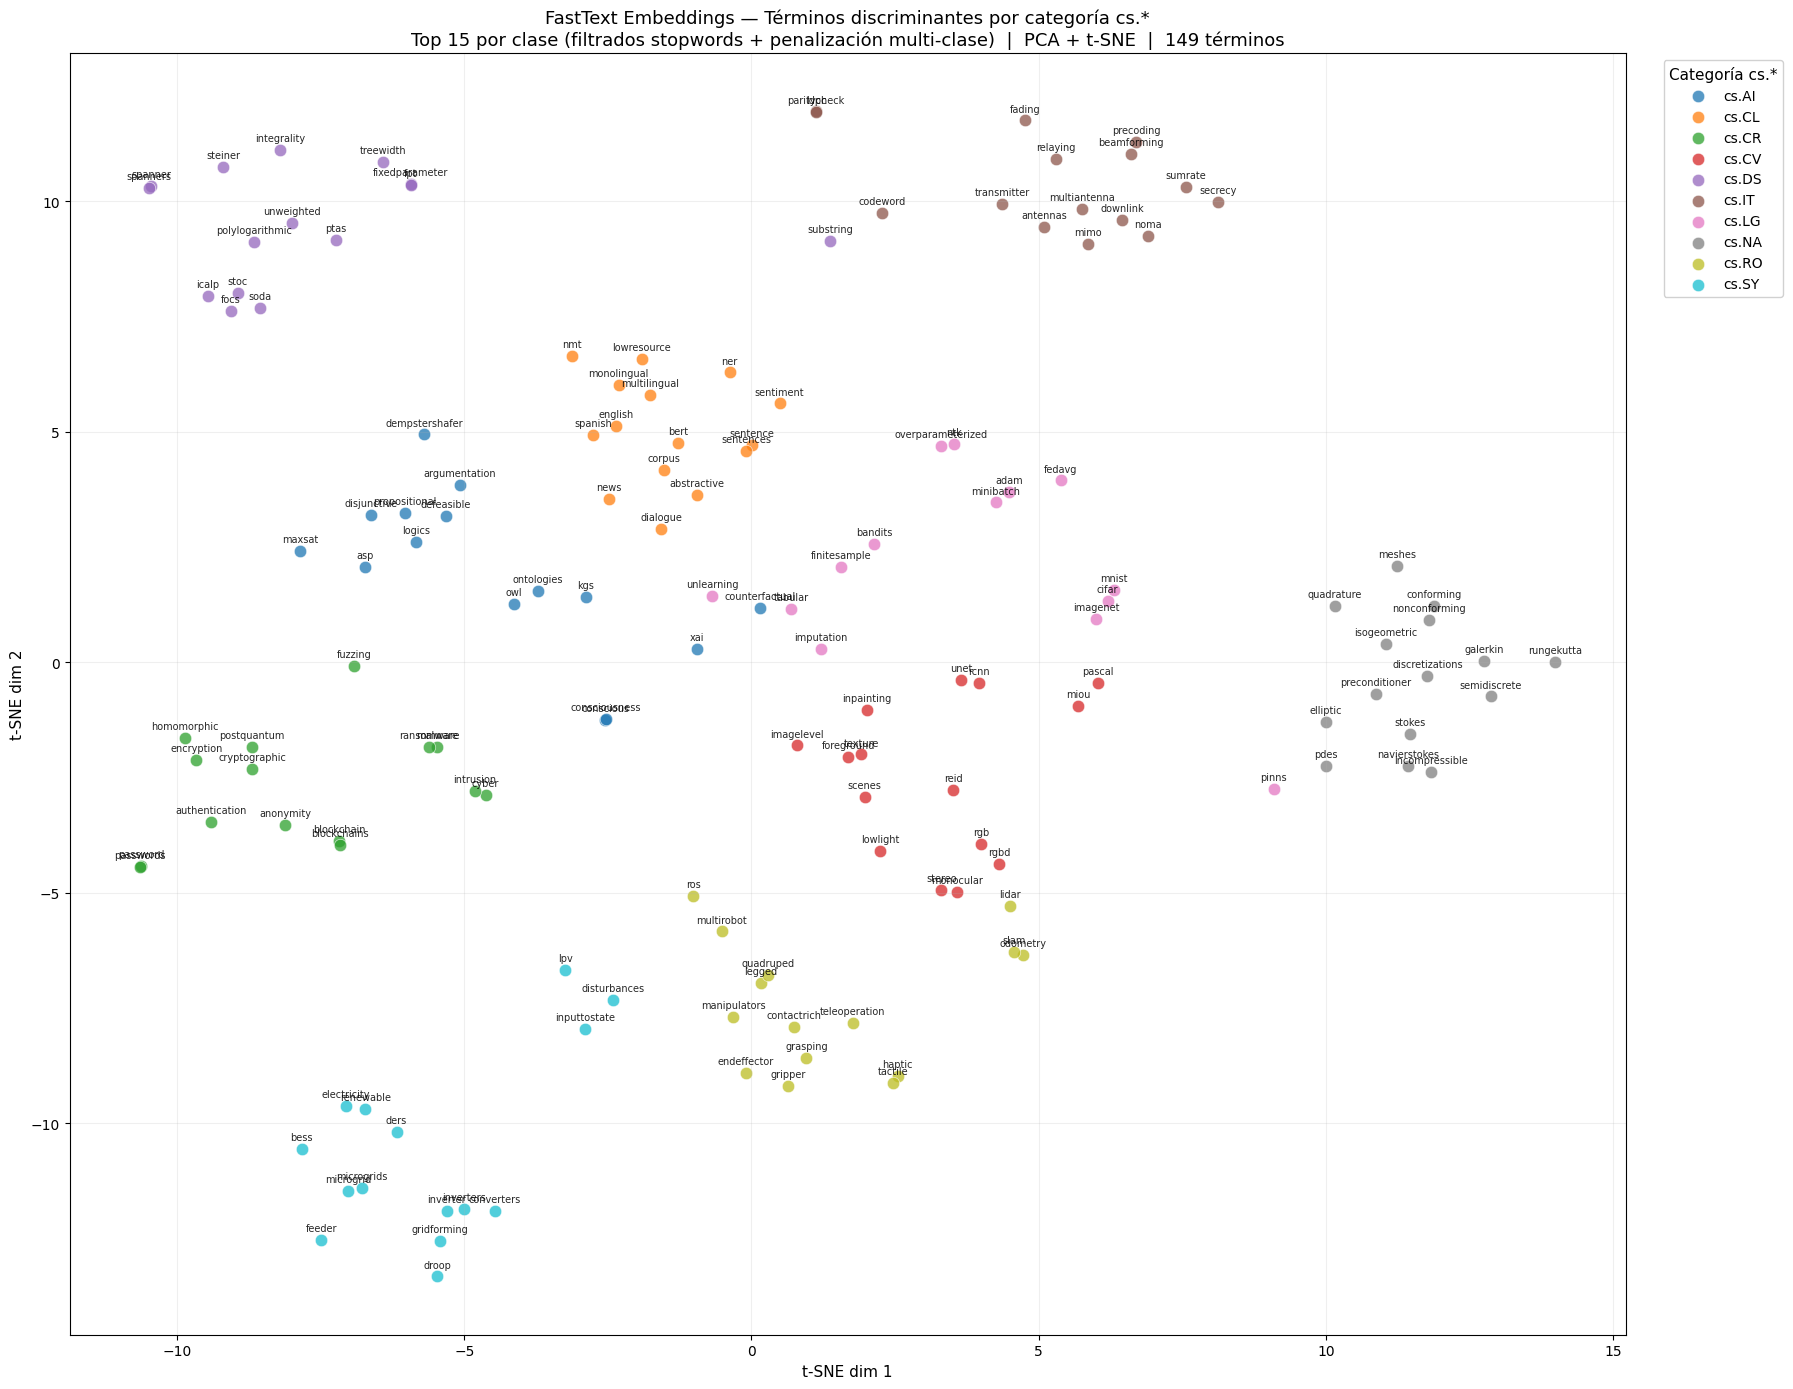

[MEM fin de visualización] RSS = 24.34 GB


In [17]:
# ============================================================
# Celda 8 (mejorada) — Visualización con PCA + t-SNE
# ============================================================
# Cambios respecto a la versión original:
#   1. Filtra stopwords y términos genéricos del corpus científico
#   2. Selecciona los top 15 términos MÁS DISCRIMINANTES por categoría
#      usando TF-IDF-like: freq(term,class)/total(class) penalizado
#      por el número de clases donde aparece el término
#   3. Elimina términos que aparecen en más de 5 categorías
#   4. Resultado: ~150 términos altamente discriminantes por dominio
# ============================================================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# --- 8a. Stopwords extendidas para corpus científico ---
science_stopwords = set(ENGLISH_STOP_WORDS) | {
    # Palabras funcionales académicas
    "proposed", "propose", "proposes", "based", "using", "used", "use",
    "approach", "approaches", "method", "methods", "model", "models",
    "paper", "show", "shows", "shown", "results", "result",
    "problem", "problems", "novel", "new", "recent", "also",
    "well", "can", "one", "two", "first", "present", "work",
    "provide", "provides", "study", "demonstrate", "demonstrates",
    "achieve", "achieves", "achieved", "improve", "improved",
    "performance", "existing", "different", "various", "several",
    "significant", "significantly", "high", "large", "better",
    "compared", "framework", "technique", "techniques", "system",
    "systems", "set", "data", "number", "order", "case", "given",
    "general", "particular", "need", "make", "without", "however",
    "including", "multiple", "potential", "available", "address",
    "challenges", "research", "solution", "analysis", "design",
    "effective", "effectiveness", "applications", "application",
    "complex", "structure", "representation", "evaluation",
    "process", "information", "further", "across", "human",
    "trained", "training", "learning", "specific", "best",
    "consider", "possible", "features", "feature", "key",
    "real", "realworld", "stateoftheart", "task", "tasks",
    "attention", "local", "function", "parameters", "generation",
    "loss", "optimal", "optimization", "error", "quality",
    "accuracy", "efficient", "robust", "knowledge", "domain",
}

# --- 8b. Calcular frecuencia por categoría (solo datos originales) ---
print("Cargando datos para asociación término → categoría...")
df_assoc = pd.read_parquet(ARXIV_TOP10_AUG, columns=["texto_limpio", "cs_primary", "aug_method"])
df_orig = df_assoc[df_assoc["aug_method"] == "original"]

categories = sorted(df_orig["cs_primary"].unique().tolist())

# Contar tokens por categoría
class_token_counts = {}
class_totals = {}
for cat in categories:
    texts_cat = df_orig.loc[df_orig["cs_primary"] == cat, "texto_limpio"].dropna()
    counter = Counter()
    for text in texts_cat:
        counter.update(clean_and_tokenize(text))
    class_token_counts[cat] = counter
    class_totals[cat] = sum(counter.values())

del df_assoc, df_orig

# --- 8c. Seleccionar términos discriminantes por categoría ---
# Para cada término calculamos:
#   score = (freq_in_class / total_class) / num_classes_where_appears
# Esto penaliza términos que aparecen en muchas categorías.

print("Seleccionando términos discriminantes por categoría...")

TERMS_PER_CAT = 15
MIN_FREQ = 50  # Frecuencia mínima en la categoría para considerar el término

# Contar en cuántas categorías aparece cada término (con freq >= MIN_FREQ)
term_class_presence = Counter()
for cat in categories:
    for term, freq in class_token_counts[cat].items():
        if freq >= MIN_FREQ:
            term_class_presence[term] += 1

selected_terms = set()
terms_by_category = {}

for cat in categories:
    scored = []
    for term, freq in class_token_counts[cat].items():
        # Filtros
        if term in science_stopwords:
            continue
        if len(term) < 3:
            continue
        if freq < MIN_FREQ:
            continue
        if term not in vocab2idx:
            continue
        # No usar términos que aparecen en más de 5 categorías
        if term_class_presence.get(term, 0) > 5:
            continue

        # Score: frecuencia relativa penalizada por presencia en múltiples clases
        rel_freq = freq / class_totals[cat]
        penalty = term_class_presence.get(term, 1)
        score = rel_freq / penalty

        scored.append((term, score))

    # Top N por categoría
    scored.sort(key=lambda x: x[1], reverse=True)
    top_terms = [t for t, _ in scored[:TERMS_PER_CAT]]
    terms_by_category[cat] = top_terms
    selected_terms.update(top_terms)

# Asignar cada término a su categoría principal
term_to_category = {}
for cat, terms in terms_by_category.items():
    for t in terms:
        if t not in term_to_category:
            term_to_category[t] = cat

selected_list = sorted(selected_terms)
print(f"\nTérminos seleccionados: {len(selected_list)}")
print("\nDistribución por categoría:")
cat_counts = Counter(term_to_category.values())
for cat in categories:
    terms_str = ", ".join(terms_by_category.get(cat, [])[:5])
    print(f"   {cat}: {cat_counts.get(cat, 0):>3}  ({terms_str}, ...)")

# --- 8d. Extraer vectores ---
vectors_sel = np.array([embedding_matrix[vocab2idx[t]] for t in selected_list])
labels_sel = [term_to_category[t] for t in selected_list]

# --- 8e. PCA (300D → 50D) + t-SNE (50D → 2D) ---
print(f"\nReduciendo dimensionalidad: PCA(50D) → t-SNE(2D)...")

pca = PCA(n_components=50, random_state=42)
vectors_pca = pca.fit_transform(vectors_sel)
print(f"   PCA: varianza explicada = {pca.explained_variance_ratio_.sum()*100:.1f}%")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(selected_list) - 1), max_iter=1000)
vectors_2d = tsne.fit_transform(vectors_pca)
print("   t-SNE: completado.")

# --- 8f. Graficar ---
fig, ax = plt.subplots(figsize=(18, 14))

palette = sns.color_palette("tab10", n_colors=len(categories))
cat_to_color = {cat: palette[i] for i, cat in enumerate(categories)}

for cat in categories:
    mask = [i for i, l in enumerate(labels_sel) if l == cat]
    if not mask:
        continue
    ax.scatter(
        vectors_2d[mask, 0], vectors_2d[mask, 1],
        c=[cat_to_color[cat]], label=cat, s=80, alpha=0.75,
        edgecolors='white', linewidths=0.5
    )

# Anotar términos
for i, term in enumerate(selected_list):
    ax.annotate(
        term,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        fontsize=7, alpha=0.85,
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )

ax.set_title(
    "FastText Embeddings — Términos discriminantes por categoría cs.*\n"
    f"Top {TERMS_PER_CAT} por clase (filtrados stopwords + penalización multi-clase)  |  "
    f"PCA + t-SNE  |  {len(selected_list)} términos",
    fontsize=13
)
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(
    title="Categoría cs.*", bbox_to_anchor=(1.02, 1), loc='upper left',
    fontsize=10, title_fontsize=11, framealpha=0.9
)
ax.grid(True, alpha=0.2)
plt.tight_layout()

fig.savefig("embedding_tsne_discriminante.png", dpi=150, bbox_inches='tight')
print(f"\n Figura guardada: embedding_tsne_discriminante_1.png")
plt.show()

report_memory("fin de visualización")

---
## Resumen de artefactos generados

| Archivo | Descripción |
|---------|-------------|
| `fasttext_cs_wiki.model` | Modelo FastText entrenado (skip-gram, 300D) |
| `embedding_matrix.npy` | Matriz de embeddings (vocab_size × 300), compatible con PyTorch |
| `vocab2idx.pkl` | Diccionario token → índice (idx 0 = `<PAD>`, idx 1 = `<UNK>`) |
| `embedding_tsne_top200.png` | Visualización t-SNE de los 200 términos más frecuentes |

### Siguiente paso → Fase 4
Cargar `embedding_matrix.npy` y `vocab2idx.pkl` como capa `nn.Embedding` pre-inicializada en la BiLSTM de clasificación.